In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sqlite3
#import papermill as pm
from datetime import datetime, timedelta
from tqdm import tqdm
import re

### 1.1 Load and Inspect the Data 

db_path = "./data.db"
table_name = "signals"

conn = sqlite3.connect(db_path)
# Use a clean string for column names
query = "SELECT id, symbol, date, open, high, low, close, volume, adj_close, vwap, market_cap FROM signals"

# Load the data
df = pd.read_sql(query, conn)

df.info()
df.describe()
df.head()

!pip install joblib

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9697099 entries, 0 to 9697098
Data columns (total 11 columns):
 #   Column      Dtype  
---  ------      -----  
 0   id          int64  
 1   symbol      object 
 2   date        object 
 3   open        float64
 4   high        float64
 5   low         float64
 6   close       float64
 7   volume      int64  
 8   adj_close   float64
 9   vwap        float64
 10  market_cap  float64
dtypes: float64(7), int64(2), object(2)
memory usage: 813.8+ MB


You should consider upgrading via the 'c:\python38\python.exe -m pip install --upgrade pip' command.


In [2]:
data = df[['id', 'symbol', 'date', 'open', 'high', 'low', 'close', 'volume','adj_close', 'vwap','market_cap']]
data["date"] = pd.to_datetime(data["date"])
stocks_data= data[data["symbol"] != "^SP500TR"].reset_index(drop=True)

benchmark_data = data[data["symbol"] == "^SP500TR"].reset_index(drop=True)
benchmark_data=benchmark_data.sort_values(by=["symbol","date"], ascending=[True, True])

In [3]:
### 1.1 Data Cleaning

# Check for missing values
missing_values = stocks_data.isnull().sum()
print("Missing values per column:")
print(missing_values)

print(stocks_data[stocks_data['vwap'].isnull()]['symbol'].unique())
# Calculate the Typical Price: (High + Low + Close) / 3
typical_price = (stocks_data['high'] + stocks_data['low'] + stocks_data['close']) / 3

# Fill only the missing VWAP values with the Typical Price
stocks_data['vwap'] = stocks_data['vwap'].fillna(typical_price)

print("No duplicate rows", stocks_data[stocks_data.duplicated(subset=['symbol', 'date'], keep=False)])

# treating anomalies

print(stocks_data[stocks_data["high"] < stocks_data["close"]]["symbol"].count())
print(stocks_data[stocks_data["low"] >stocks_data["close"]]["symbol"].count())


# Set High to be the maximum of High and Close
stocks_data['high'] = np.maximum(stocks_data['high'], stocks_data['close'])

# Do the same for Low (ensure Low is never higher than Close)
stocks_data['low'] = np.minimum(stocks_data['low'], stocks_data['close'])

Missing values per column:
id             0
symbol         0
date           0
open           0
high           0
low            0
close          0
volume         0
adj_close      0
vwap          20
market_cap     0
dtype: int64
['ARDS' 'WTER' 'CLVR']
No duplicate rows Empty DataFrame
Columns: [id, symbol, date, open, high, low, close, volume, adj_close, vwap, market_cap]
Index: []
49
13


In [4]:
# -----------------------------
# Proper Date Splits (As per HW)
# -----------------------------

train_end = "2020-01-01"
gap_start = "2020-01-01"
gap_end   = "2020-03-31"
test_start = "2020-04-01"

train_df = stocks_data[
    stocks_data["date"] <= train_end
].copy()

test_df = stocks_data[
    stocks_data["date"] >= test_start
].copy()

print("Train:", train_df["date"].min(), "→", train_df["date"].max())
print("Test :", test_df["date"].min(), "→", test_df["date"].max())

Train: 2015-01-02 00:00:00 → 2019-12-31 00:00:00
Test : 2020-04-01 00:00:00 → 2025-12-31 00:00:00


In [5]:
def compute_target(df):

    df = df.sort_values(["symbol", "date"])

    df["Target_90d"] = (
        df.groupby("symbol")["adj_close"]
          .shift(-90) / df["adj_close"] - 1
    )

    return df


In [6]:
test_df=compute_target(test_df)
train_df=compute_target(train_df)

In [7]:
def build_features(df):
    """
    Build technical features for stock return prediction.
    Assumes df has: symbol, date, adj_close, volume
    Returns df with new feature columns added.
    """

    df = df.sort_values(["symbol", "date"]).copy()

    # Group objects
    price_g = df.groupby("symbol")["adj_close"]
    vol_g   = df.groupby("symbol")["volume"]

    # -----------------------------
    # Momentum
    # -----------------------------
    for d in [7, 30, 60, 90]:
        df[f"Momentum_{d}d"] = price_g.pct_change(d).astype("float32")


    # -----------------------------
    # Volatility
    # -----------------------------
    daily_ret = price_g.pct_change()

    df["Volatility_30d"] = (
        daily_ret
        .groupby(df["symbol"])
        .rolling(30)
        .std()
        .reset_index(level=0, drop=True)
        .astype("float32")
    )


    # -----------------------------
    # Moving Averages
    # -----------------------------
    for d in [7, 30, 60, 200]:
        df[f"MA_{d}d"] = (
            price_g
            .transform(lambda x: x.rolling(d).mean())
            .astype("float32")
        )


    # -----------------------------
    # Ratios
    # -----------------------------
    df["Mom_30_90_ratio"] = (
        df["Momentum_30d"] / df["Momentum_90d"]
    ).astype("float32")

    df["MA_7_30_ratio"] = (
        df["MA_7d"] / df["MA_30d"]
    ).astype("float32")

    df["MA_30_200_ratio"] = (
        df["MA_30d"] / df["MA_200d"]
    ).astype("float32")

    df["Mom30_vol30"] = (
        df["Momentum_30d"] / df["Volatility_30d"]
    ).astype("float32")


    # -----------------------------
    # Range Position
    # -----------------------------
    for d in [30, 90]:

        rolling_max = price_g.transform(
            lambda x: x.rolling(d).max()
        )

        rolling_min = price_g.transform(
            lambda x: x.rolling(d).min()
        )

        df[f"RangePos_{d}d"] = (
            (df["adj_close"] - rolling_min) /
            (rolling_max - rolling_min)
        ).astype("float32")


    # -----------------------------
    # Volume Z-score
    # -----------------------------
    vol_mean = vol_g.transform(lambda x: x.rolling(30).mean())
    vol_std  = vol_g.transform(lambda x: x.rolling(30).std())

    df["Volume_z30"] = (
        (df["volume"] - vol_mean) / vol_std
    ).astype("float32")


    # -----------------------------
    # Volume × Momentum
    # -----------------------------
    df["VolMom_30"] = (
        df["Momentum_30d"] * df["Volume_z30"]
    ).astype("float32")


    # -----------------------------
    # Cross-sectional Ranks
    # -----------------------------
    for col in ["Momentum_30d", "Momentum_90d", "Volatility_30d"]:

        df[f"{col}_rank"] = (
            df.groupby("date")[col]
              .rank(pct=True)
              .astype("float32")
        )


    # -----------------------------
    # MA Spread
    # -----------------------------
    df["ma_spread_pct"] = (
        (df["MA_30d"] - df["MA_200d"]) / df["MA_200d"]
    ).astype("float32")


    return df


In [8]:
# Build features separately
train = build_features(train_df)
test  = build_features(test_df)

# Drop NaNs from rolling windows
train = train.dropna()
test  = test.dropna()

In [9]:
train_df

,id,symbol,date,open,high,low,close,volume,adj_close,vwap,market_cap,Target_90d
11428,9303879,A,2015-01-02,41.1800,41.3100,40.3700,40.5600,1530798,37.420000,40.8550,1.354704e+10,0.033405
156,9303878,A,2015-01-05,40.3200,40.4600,39.7000,39.8000,2042240,36.720000,40.0700,1.329320e+10,0.059096
3800,9303877,A,2015-01-06,39.8100,40.0200,39.0200,39.1800,2084562,36.150000,39.5075,1.308612e+10,0.075519
26234,9303876,A,2015-01-07,39.5200,39.8100,39.2900,39.7000,3359700,36.630000,39.5800,1.325980e+10,0.076440
41139,9303875,A,2015-01-08,40.2400,40.9800,40.1800,40.8900,2116341,37.730000,40.5725,1.365726e+10,0.038696
...,...,...,...,...,...,...,...,...,...,...,...,...
3721410,21304105,ZYXI,2019-12-24,7.1636,7.4364,7.0550,7.4091,147524,7.327835,7.3200,2.647938e+08,NaN
3726158,21304104,ZYXI,2019-12-26,7.3727,7.5091,7.1909,7.3091,139693,7.228932,7.3100,2.612199e+08,NaN
3731056,21304103,ZYXI,2019-12-27,7.2909,7.6273,7.2364,7.3182,260770,7.237923,7.4100,2.615451e+08,NaN
3732343,21304102,ZYXI,2019-12-30,7.3182,7.3818,7.0455,7.2364,162856,7.157002,7.2200,2.586217e+08,NaN


In [10]:
# Shift features by 1 day to avoid look-ahead bias

feature_cols = [c for c in train.columns if c not in ["symbol","date","adj_close","volume"]]

train[feature_cols] = train.groupby("symbol")[feature_cols].shift(1)
test[feature_cols]  = test.groupby("symbol")[feature_cols].shift(1)


In [11]:
feature_cols = [
    'Momentum_7d','Momentum_30d','Momentum_60d','Momentum_90d',
    'Volatility_30d',
    'Mom_30_90_ratio','RangePos_30d','RangePos_90d',
    'MA_7_30_ratio','Mom30_vol30','Volume_z30','VolMom_30',
    'Momentum_30d_rank','Momentum_90d_rank',
    'Volatility_30d_rank','ma_spread_pct'
]


keep_cols = ["symbol","date","adj_close","Target_90d"] + feature_cols

train = train[keep_cols]
test  = test[keep_cols]

train = train.replace([np.inf, -np.inf], np.nan)
test  = test.replace([np.inf, -np.inf], np.nan)

train = train.dropna()
test  = test.dropna()

low, high = train["Target_90d"].quantile([0.01, 0.99])

train["Target_clip"] = train["Target_90d"].clip(low, high)
test["Target_clip"]  = test["Target_90d"].clip(low, high)

X_train = train[feature_cols]
y_train = train["Target_clip"]

X_test = test[feature_cols]
y_test = test["Target_90d"]   # for evaluation only



In [12]:
from sklearn.ensemble import RandomForestRegressor



# -----------------------------
# Random Forest (Tuned for Stability)
# -----------------------------

# Reduce size
MAX_ROWS = 500_000

if len(X_train) > MAX_ROWS:
    idx = X_train.sample(MAX_ROWS, random_state=42).index
    X_train = X_train.loc[idx]
    y_train = y_train.loc[idx]

rf = RandomForestRegressor(
    n_estimators=80,
    max_depth=10,
    min_samples_leaf=50,
    max_samples=0.5,
    n_jobs=-1,
    random_state=42
)



# -----------------------------
# Train
# -----------------------------

print(f"Training on {len(X_train):,} samples...")
rf.fit(X_train, y_train)

print("Training complete.")


Training on 500,000 samples...
Training complete.


In [13]:
import joblib

# 'rf' is the name of the model you trained in your code snippet earlier
joblib.dump(rf, 'model.joblib')

print("Model saved successfully as model.joblib!")

Model saved successfully as model.joblib!


In [13]:
def backtest_strategy_realistic(
    data,
    model,
    features,
    initial_cash=1_000_000,
    top_k=5,
    holding_days=90,
    max_capital_fraction=0.2
):

    df = data.copy()
    df = df.sort_values(["date", "symbol"])

    # Generate predictions
    df["pred"] = model.predict(df[features])

    all_dates = df["date"].unique()

    cash = initial_cash
    positions = []      # open positions
    history = []

    # Pre-index for speed
    price_lookup = df.set_index(["date", "symbol"])["adj_close"]

    for today in all_dates:

        # -----------------------------
        # 1. EXIT POSITIONS
        # -----------------------------
        new_positions = []

        for pos in positions:

            if today >= pos["exit_date"]:

                try:
                    exit_price = price_lookup.loc[(today, pos["symbol"])]
                    cash += pos["shares"] * exit_price
                except:
                    # If no price today, keep position
                    new_positions.append(pos)

            else:
                new_positions.append(pos)

        positions = new_positions


        # -----------------------------
        # 2. ENTER POSITIONS
        # -----------------------------
        today_data = df[df["date"] == today]

        held = {p["symbol"] for p in positions}

        candidates = (
            today_data[
                (today_data["pred"] > 0) &
                (~today_data["symbol"].isin(held))
            ]
            .nlargest(top_k, "pred")
        )

        if len(candidates) > 0 and cash > 0:

            deployable = cash * max_capital_fraction
            invest_each = deployable / len(candidates)

            for _, row in candidates.iterrows():

                price = row["adj_close"]
                shares = invest_each / price

                positions.append({
                    "symbol": row["symbol"],
                    "entry_date": today,
                    "exit_date": today + pd.Timedelta(days=holding_days),
                    "shares": shares
                })

                cash -= invest_each


        # -----------------------------
        # 3. MARK TO MARKET
        # -----------------------------
        portfolio_value = cash

        for pos in positions:

            try:
                price = price_lookup.loc[(today, pos["symbol"])]
                portfolio_value += pos["shares"] * price
            except:
                pass


        history.append({
            "date": today,
            "portfolio_value": portfolio_value,
            "cash": cash,
            "open_positions": len(positions)
        })


    return pd.DataFrame(history)


In [14]:
results = backtest_strategy_realistic(
    test,
    rf,
    feature_cols,
    initial_cash=1_000_000,
    top_k=5,
    holding_days=90,
    max_capital_fraction=0.2
)

results["date"] = pd.to_datetime(results["date"])
results = results.set_index("date")

results.head()


,portfolio_value,cash,open_positions
date,,,
2021-01-15,1.000000e+06,800000.0,5
2021-01-19,1.003226e+06,640000.0,10
2021-01-20,9.990003e+05,512000.0,15
2021-01-21,9.962349e+05,409600.0,20
2021-01-22,9.943657e+05,327680.0,25


In [ ]:
returns = results["portfolio_value"].pct_change().dropna()


def calculate_annualized_return(start, end, years):
    return (end / start) ** (1 / years) - 1


def calculate_max_drawdown(values):
    peak = values.cummax()
    dd = (values - peak) / peak
    return dd.min()


def calculate_sharpe(returns, rf=0.02):
    excess = returns.mean() * 252 - rf
    vol = returns.std() * np.sqrt(252)
    return excess / vol


start = results["portfolio_value"].iloc[0]
end = results["portfolio_value"].iloc[-1]

years = (results.index[-1] - results.index[0]).days / 365.25


final_value = end

benchmark = benchmark_data.copy()
benchmark["date"] = pd.to_datetime(benchmark["date"])
benchmark = benchmark.set_index("date")

benchmark = benchmark.loc[results.index.min():results.index.max()]

sp_returns = benchmark["adj_close"].pct_change().dropna()

strategy_cum = (1 + returns).cumprod()
sp_cum = (1 + sp_returns).cumprod()

common = strategy_cum.index.intersection(sp_cum.index)

strategy_cum = strategy_cum.loc[common]
sp_cum = sp_cum.loc[common]





In [24]:
# -----------------------------
# Strategy Metrics
# -----------------------------

start_val = results["portfolio_value"].iloc[0]
end_val   = results["portfolio_value"].iloc[-1]

years = (results.index[-1] - results.index[0]).days / 365.25

strategy_ann_return = calculate_annualized_return(
    start_val, end_val, years
)

strategy_max_dd = calculate_max_drawdown(
    results["portfolio_value"]
)

strategy_sharpe = calculate_sharpe(
    returns, rf=0.02
)


# -----------------------------
# Benchmark Metrics
# -----------------------------

bench_start = benchmark["adj_close"].iloc[0]
bench_end   = benchmark["adj_close"].iloc[-1]

bench_ann_return = calculate_annualized_return(
    bench_start, bench_end, years
)


# -----------------------------
# Comparison
# -----------------------------

outperformance = strategy_ann_return - bench_ann_return
beat_benchmark = "Yes" if outperformance > 0 else "No"


# -----------------------------
# Print Required Output
# -----------------------------

print("\n============ PORTFOLIO PERFORMANCE ============")

print(f"Final Portfolio Value:    ${end_val:,.2f}")
print(f"Annualized Return:        {strategy_ann_return*100:.2f}%")
print(f"Maximum Drawdown:         {strategy_max_dd*100:.2f}%")
print(f"Sharpe Ratio:             {strategy_sharpe:.2f}")

print("\n============ BENCHMARK (S&P 500) ============")

print(f"Final Value:              ${bench_end:,.2f}")
print(f"Annualized Return:        {bench_ann_return*100:.2f}%")

print("\n============ RESULT ============")

print(f"Beat Benchmark:           {beat_benchmark}")
print(f"Outperformance:           {outperformance*100:+.2f}%")

print("===============================================")



============ PORTFOLIO PERFORMANCE ============
Final Portfolio Value:    $3,970,636.73
Annualized Return:        34.96%
Maximum Drawdown:         -98.54%
Sharpe Ratio:             0.91

============ BENCHMARK (S&P 500) ============
Final Value:              $12,827.63
Annualized Return:        11.45%

============ RESULT ============
Beat Benchmark:           Yes
Outperformance:           +23.50%


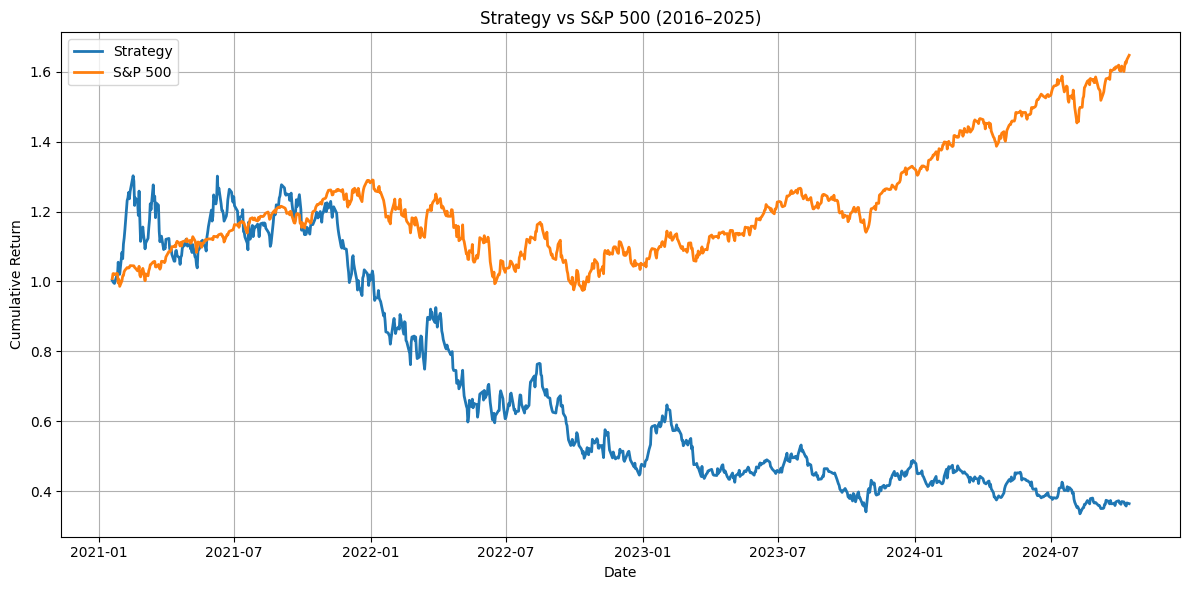

In [17]:
plt.figure(figsize=(12,6))

plt.plot(strategy_cum, label="Strategy", linewidth=2)
plt.plot(sp_cum, label="S&P 500", linewidth=2)

plt.title("Strategy vs S&P 500 (2016–2025)")
plt.xlabel("Date")
plt.ylabel("Cumulative Return")

plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()
